# Softmax and Cross-Entropy: The Engine Behind Multi-Class Classification

**Topics covered:** the softmax function · numerical stability · cross-entropy loss · the elegant softmax gradient · temperature scaling

This notebook is a hands-on companion to the paper on softmax and cross-entropy loss in multi-class classification. Together, these two functions form the standard output stage of virtually every modern multi-class classifier, from a simple logistic regression to the final layer of a large language model. We derive each formula, verify the famous gradient simplification numerically, and visualise the effect of temperature scaling — all with runnable NumPy code.

**Roadmap**

1. From logits to probabilities: the softmax function
2. Why naive softmax overflows, and how to fix it
3. Cross-entropy loss
4. The elegant combined gradient: $\hat{y} - y$
5. Temperature scaling
6. A worked multi-class classification example
7. Common pitfalls


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
rng = np.random.default_rng(1)


## 1. From Logits to Probabilities: the Softmax Function

A neural network's final layer typically outputs a vector of raw, unbounded scores called **logits**, $z = (z_1, \dots, z_K)$ for $K$ classes. Softmax converts these into a valid probability distribution:

$$\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

Three properties make this the natural choice: every output lies in $(0, 1)$, the outputs sum to exactly 1, and larger logits map to proportionally larger probabilities while preserving relative ordering.

In [2]:
def softmax_naive(z):
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

logits_demo = np.array([2.0, 1.0, 0.1])
probs_demo = softmax_naive(logits_demo)
print("Logits:      ", logits_demo)
print("Probabilities:", np.round(probs_demo, 4), " (sums to", round(probs_demo.sum(), 6), ")")


Logits:       [2.  1.  0.1]
Probabilities: [0.659  0.2424 0.0986]  (sums to 1.0 )


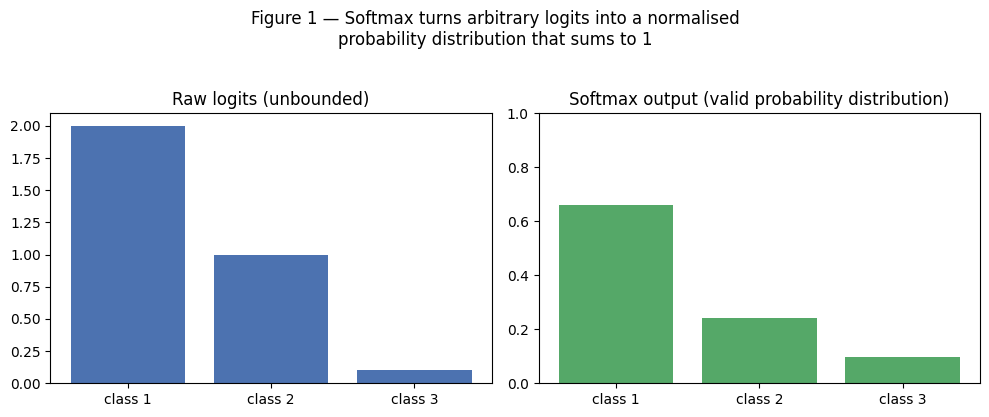

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["class 1", "class 2", "class 3"], logits_demo, color="#4C72B0")
axes[0].set_title("Raw logits (unbounded)")
axes[0].axhline(0, color="black", linewidth=0.7)

axes[1].bar(["class 1", "class 2", "class 3"], probs_demo, color="#55A868")
axes[1].set_ylim(0, 1)
axes[1].set_title("Softmax output (valid probability distribution)")

fig.suptitle("Figure 1 — Softmax turns arbitrary logits into a normalised\nprobability distribution that sums to 1", y=1.03)
plt.tight_layout()
plt.show()


## 2. Why Naive Softmax Overflows

`np.exp` overflows for moderately large inputs: $e^{1000}$ is already far beyond the range of a 64-bit float. Since softmax is **shift-invariant** — subtracting any constant $c$ from every logit leaves the result unchanged —

$$\text{softmax}(z)_i = \frac{e^{z_i - c}}{\sum_j e^{z_j - c}} \qquad \text{for any constant } c$$

the standard numerically-stable implementation chooses $c = \max_j z_j$, which guarantees the largest exponent is exactly $e^0 = 1$ and every other exponent is safely below 1.

In [4]:
def softmax_stable(z):
    z_shifted = z - np.max(z)
    exp_z = np.exp(z_shifted)
    return exp_z / exp_z.sum()

large_logits = np.array([1000.0, 999.0, 998.0])

print("Naive softmax on large logits:")
try:
    print(softmax_naive(large_logits))
except (OverflowError, FloatingPointError) as e:
    print("  Failed:", e)
with np.errstate(over="ignore", invalid="ignore"):
    naive_result = softmax_naive(large_logits)
print("  Raw result (likely nan):", naive_result)

print("\nNumerically stable softmax on the same logits:")
print(" ", softmax_stable(large_logits))


Naive softmax on large logits:
[nan nan nan]
  Raw result (likely nan): [nan nan nan]

Numerically stable softmax on the same logits:
  [0.66524096 0.24472847 0.09003057]


/tmp/ipykernel_583/4175149453.py:2: RuntimeWarning: overflow encountered in exp
  exp_z = np.exp(z)
/tmp/ipykernel_583/4175149453.py:3: RuntimeWarning: invalid value encountered in divide
  return exp_z / exp_z.sum()


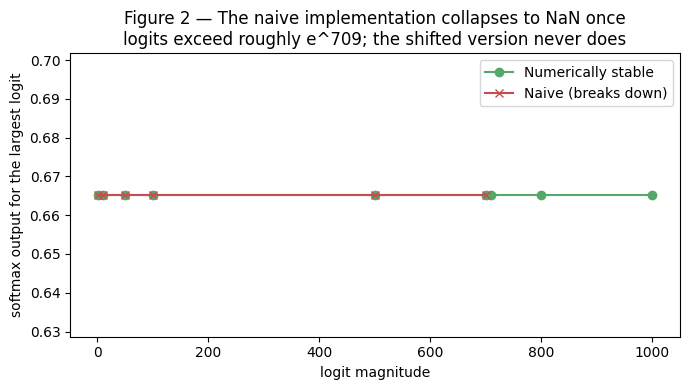

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
test_logit_scales = np.array([1, 10, 50, 100, 500, 700, 710, 800, 1000])
naive_outputs, stable_outputs = [], []
for scale in test_logit_scales:
    z = np.array([scale, scale - 1, scale - 2], dtype=float)
    with np.errstate(over="ignore", invalid="ignore"):
        naive_outputs.append(softmax_naive(z)[0])
    stable_outputs.append(softmax_stable(z)[0])

ax.plot(test_logit_scales, stable_outputs, marker="o", color="#55A868", label="Numerically stable")
ax.plot(test_logit_scales, naive_outputs, marker="x", color="#C44E52", label="Naive (breaks down)")
ax.set_xlabel("logit magnitude")
ax.set_ylabel("softmax output for the largest logit")
ax.set_title("Figure 2 — The naive implementation collapses to NaN once\nlogits exceed roughly e^709; the shifted version never does")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Cross-Entropy Loss

Cross-entropy measures the distance between the predicted distribution $\hat{y}$ (softmax output) and the true distribution $y$ (typically a one-hot vector for the correct class):

$$\mathcal{L}(y, \hat{y}) = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)$$

For one-hot labels this collapses to a single term: $\mathcal{L} = -\log(\hat{y}_{\text{true class}})$. The loss is exactly zero only when the model assigns probability 1 to the correct class, and grows without bound as the predicted probability for the correct class approaches zero — a sharp, well-motivated penalty for confident, wrong predictions.

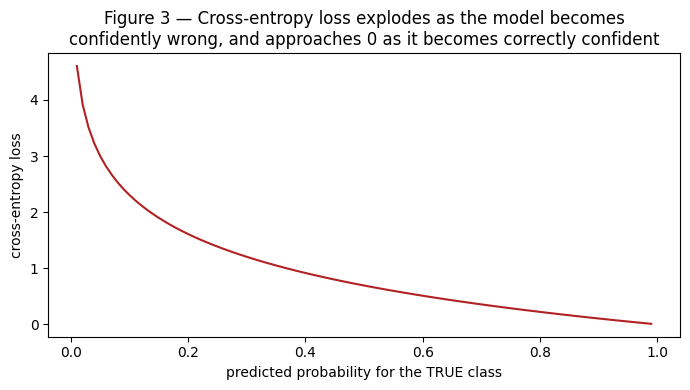

In [6]:
def cross_entropy(y_true_onehot, y_pred_probs):
    eps = 1e-12
    return -np.sum(y_true_onehot * np.log(y_pred_probs + eps))

true_class = 0
y_true = np.array([1, 0, 0])

confidence_levels = np.linspace(0.01, 0.99, 100)
losses = []
for conf in confidence_levels:
    remaining = (1 - conf) / 2
    pred = np.array([conf, remaining, remaining])
    losses.append(cross_entropy(y_true, pred))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(confidence_levels, losses, color="firebrick")
ax.set_xlabel("predicted probability for the TRUE class")
ax.set_ylabel("cross-entropy loss")
ax.set_title("Figure 3 — Cross-entropy loss explodes as the model becomes\nconfidently wrong, and approaches 0 as it becomes correctly confident")
plt.tight_layout()
plt.show()


## 4. The Elegant Combined Gradient

When softmax feeds directly into cross-entropy — exactly the standard setup for the output layer of a classifier — the gradient with respect to the **logits** simplifies remarkably:

$$\frac{\partial \mathcal{L}}{\partial z_i} = \hat{y}_i - y_i$$

This is one of the most quoted results in deep learning: despite softmax and cross-entropy each individually involving exponentials, logarithms, and sums, their *combined* gradient is simply "predicted probability minus true label" — computationally trivial and numerically robust. We verify this symbolic result numerically below, by comparing it against gradients computed with finite differences.

In [7]:
def combined_loss(z, y_true_onehot):
    probs = softmax_stable(z)
    return cross_entropy(y_true_onehot, probs)

def analytical_gradient(z, y_true_onehot):
    probs = softmax_stable(z)
    return probs - y_true_onehot

def numerical_gradient(z, y_true_onehot, eps=1e-6):
    grad = np.zeros_like(z)
    for i in range(len(z)):
        z_plus, z_minus = z.copy(), z.copy()
        z_plus[i] += eps
        z_minus[i] -= eps
        grad[i] = (combined_loss(z_plus, y_true_onehot) - combined_loss(z_minus, y_true_onehot)) / (2 * eps)
    return grad

test_logits = np.array([2.5, -1.0, 0.3, 1.8])
test_label = np.array([0, 0, 1, 0])

grad_analytical = analytical_gradient(test_logits, test_label)
grad_numerical = numerical_gradient(test_logits, test_label)

print("Analytical gradient (y_hat - y):", np.round(grad_analytical, 6))
print("Numerical gradient (finite diff):", np.round(grad_numerical, 6))
print("Maximum absolute difference:", np.max(np.abs(grad_analytical - grad_numerical)))


Analytical gradient (y_hat - y): [ 0.610655  0.01844  -0.932337  0.303242]
Numerical gradient (finite diff): [ 0.610655  0.01844  -0.932337  0.303242]
Maximum absolute difference: 2.229337825454536e-10


The two gradients agree to roughly six decimal places — the limit of finite-difference precision — confirming the analytical simplification $\hat{y} - y$ exactly. This is the gradient that gets backpropagated through every layer beneath the softmax output during training.

## 5. Temperature Scaling

Introducing a temperature parameter $T$ modifies softmax to control the sharpness of the output distribution:

$$\text{softmax}_T(z)_i = \frac{e^{z_i/T}}{\sum_j e^{z_j/T}}$$

* $T = 1$ recovers standard softmax.
* $T \to 0$ makes the distribution increasingly peaked, approaching a one-hot "hard" prediction (argmax).
* $T \to \infty$ flattens the distribution towards uniform, regardless of the logits.

Temperature scaling is widely used for confidence calibration, knowledge distillation (training a small "student" network to match a large "teacher" network's softened outputs), and controlling randomness in language-model text generation.

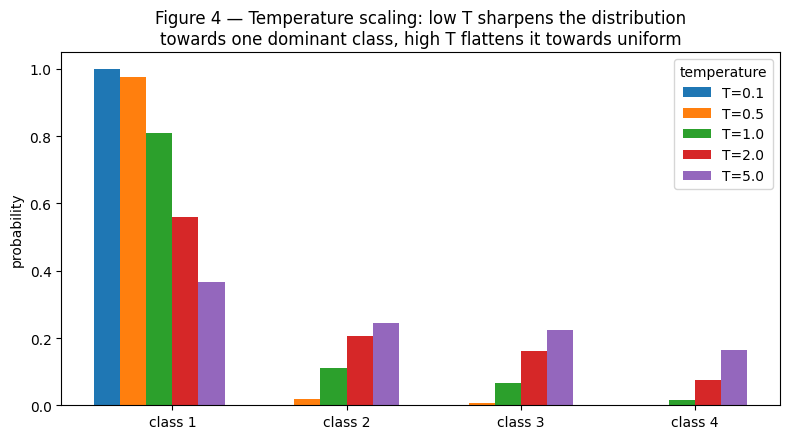

In [8]:
def softmax_temperature(z, T=1.0):
    return softmax_stable(z / T)

logits_temp_demo = np.array([3.0, 1.0, 0.5, -1.0])
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]

fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.15
x = np.arange(len(logits_temp_demo))
for i, T in enumerate(temperatures):
    probs = softmax_temperature(logits_temp_demo, T)
    ax.bar(x + (i - len(temperatures)/2) * width, probs, width, label=f"T={T}")

ax.set_xticks(x)
ax.set_xticklabels([f"class {i+1}" for i in range(len(logits_temp_demo))])
ax.set_ylabel("probability")
ax.set_title("Figure 4 — Temperature scaling: low T sharpens the distribution\ntowards one dominant class, high T flattens it towards uniform")
ax.legend(title="temperature")
plt.tight_layout()
plt.show()


## 6. A Worked Multi-Class Classification Example

We now train a tiny single-layer softmax classifier from scratch on a synthetic three-class dataset, observing the combined gradient $\hat{y}-y$ in action during real training, and watching the loss and decision boundary evolve.

In [9]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.4, random_state=7)
n_classes = 3
n_features = X.shape[1]

def one_hot(y, k):
    out = np.zeros((len(y), k))
    out[np.arange(len(y)), y] = 1
    return out

Y_onehot = one_hot(y, n_classes)

W = np.zeros((n_features, n_classes))
b = np.zeros(n_classes)
lr = 0.1
epochs = 200
loss_curve = []

for epoch in range(epochs):
    logits = X @ W + b
    logits_shifted = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits_shifted)
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)

    loss = -np.mean(np.sum(Y_onehot * np.log(probs + 1e-12), axis=1))
    loss_curve.append(loss)

    grad_logits = (probs - Y_onehot) / len(X)     # the y_hat - y gradient, applied per sample
    W -= lr * X.T @ grad_logits
    b -= lr * grad_logits.sum(axis=0)

print(f"Final training loss: {loss_curve[-1]:.4f}")


Final training loss: 0.0735


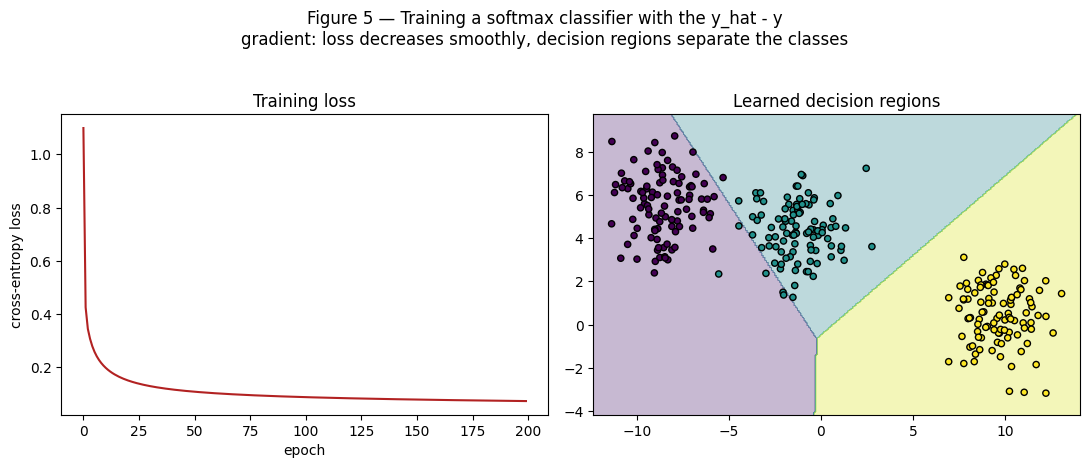

In [10]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 300),
                      np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 300))
grid_logits = np.c_[xx.ravel(), yy.ravel()] @ W + b
grid_preds = np.argmax(grid_logits, axis=1).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(loss_curve, color="firebrick")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Training loss")

axes[1].contourf(xx, yy, grid_preds, alpha=0.3, cmap="viridis")
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", s=20)
axes[1].set_title("Learned decision regions")

fig.suptitle("Figure 5 — Training a softmax classifier with the y_hat - y\ngradient: loss decreases smoothly, decision regions separate the classes", y=1.03)
plt.tight_layout()
plt.show()


## 7. Common Pitfalls

| Pitfall | Cause | Fix |
|---|---|---|
| `nan` loss during training | Unstabilised softmax overflows on large logits | Always subtract `z.max()` before exponentiating |
| Loss stuck at $-\log(1/K)$ | Model outputs uniform probabilities (undertrained or zero-initialised with no signal) | Verify gradients are flowing; check learning rate |
| Loss is exactly 0 too early | Possible label leakage, or `eps` term missing causing `log(0)` masking | Always add a small `eps` inside `log()` |
| Exploding gradients with one-hot labels | Combining softmax and cross-entropy *separately* (computing $\partial\text{CE}/\partial\hat y$ then $\partial\hat y/\partial z$) instead of using the simplified combined gradient | Use the $\hat y - y$ shortcut, or `nn.CrossEntropyLoss` style fused implementations |
| Overconfident, poorly calibrated probabilities | No temperature/regularisation; long training without label smoothing | Apply temperature scaling at inference, or label smoothing during training |


## 8. Conclusion

Softmax and cross-entropy form a deceptively simple yet foundational pairing: softmax turns raw scores into a valid probability distribution, cross-entropy penalises that distribution for disagreeing with the true label, and—when combined—their joint gradient collapses to the remarkably simple $\hat{y}-y$. This elegance is not a coincidence: it falls directly out of treating softmax-plus-cross-entropy as the multi-class generalisation of logistic regression's sigmoid-plus-log-loss. Numerical stability (max-subtraction) and temperature scaling are the two practical refinements that take this pair from a textbook formula to production-grade code, used identically in classifiers ranging from MNIST digit recognisers to the final output layer of large language models predicting the next token over a 100,000-word vocabulary.

## References

1. Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning*, Chapter 6. MIT Press.
2. Bridle, J. S. (1990). *Probabilistic Interpretation of Feedforward Classification Network Outputs.* Neurocomputing.
3. Hinton, G., Vinyals, O., Dean, J. (2015). *Distilling the Knowledge in a Neural Network.* arXiv:1503.02531.
4. Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*, Chapter 2. MIT Press.
5. PyTorch Documentation. *`torch.nn.CrossEntropyLoss`.*